In [1]:
from tqdm import tqdm
from pprint import pprint
import numpy as np

In [2]:
# -------------------------
# Constants
# -------------------------

dataset_detail=np.load("/mnt/Extra/Project_Storage/stereo_ML_dataset/org/"+"detail.npy", allow_pickle=True)
dataset_detail=dataset_detail.tolist()

patch_shape = (int(dataset_detail[0]),int(dataset_detail[1]))

target = min(int(dataset_detail[2]*0.8),int(2**14+1))
# target=1000

Dmax = int(dataset_detail[3])
Dmin = int(dataset_detail[4])

resize_fraction = dataset_detail[5]
resize_factor = 1/resize_fraction

feature_dimension =int (dataset_detail[6])

disparity_skip = int(dataset_detail[7])

eff_Dmax = (Dmax-Dmin)//(disparity_skip+1)


In [3]:

org_path = "/mnt/Extra/Project_Storage/stereo_ML_dataset/"
dataset_org_path = "/mnt/Extra/Project_Storage/stereo_ML_dataset/train/"

# -------------------------
# Load memmap datasets
# -------------------------
left_patch_memmap = dataset_org_path + "left_patch.dat"
# left_feat_memmap = dataset_org_path + "left_feat.dat"
right_strip_memmap = dataset_org_path + "right_strip.dat"
# right_feat_memmap = dataset_org_path + "right_feat.dat"
patch_disparity_memmap = dataset_org_path + "patch_disp.dat"


model_location = org_path+"model/"

left_patches  = np.memmap(left_patch_memmap, dtype=np.float16, mode='r', shape=(target, patch_shape[0], patch_shape[1]))
# patch_feat =np.memmap(left_feat_memmap, dtype=np.float16, mode='r', shape=(target, feature_dimension))

right_strips  = np.memmap(right_strip_memmap, dtype=np.float16, mode='r', shape=(target, eff_Dmax, patch_shape[0], patch_shape[1] ))
# strip_feat =np.memmap(right_feat_memmap, dtype=np.float16, mode='r', shape=(target,  eff_Dmax, feature_dimension))

median_disp   = np.memmap(patch_disparity_memmap, dtype=np.int16, mode='r', shape=(target,))

# default_mask = np.ones((target, eff_Dmax), dtype=np.bool_)



In [4]:
import numpy as np
import cv2
from skimage.feature import local_binary_pattern
from scipy.fftpack import dct

def compute_patch_features(patch, feature_mask=None, eps=1e-6):
    patch = patch.astype(np.float32)
    H, W = patch.shape
    patch_normal = (patch * 255).astype(np.uint8)

    all_features = []

    # Feature mask defaults to all True if None
    if feature_mask is None:
        feature_mask = [True]*14

    # 1. Mean
    if feature_mask[0]:
        mean_val = patch.mean()
        all_features.append(mean_val)

    # 2. Std
    if feature_mask[1]:
        std_val = np.std(patch) / 0.5
        all_features.append(std_val)

    # 3. Skew
    if feature_mask[2]:
        mean_val = patch.mean() if 'mean_val' not in locals() else mean_val
        skew_val = np.mean(((patch - mean_val) / (np.std(patch) + eps))**3)
        skew_val = (skew_val + 2)/4
        all_features.append(skew_val)

    # 4. Kurtosis
    if feature_mask[3]:
        mean_val = patch.mean() if 'mean_val' not in locals() else mean_val
        kurt_val = np.mean(((patch - mean_val) / (np.std(patch) + eps))**4)
        kurt_val = (kurt_val - 1)/8
        all_features.append(kurt_val)

    # 5. Laplacian energy
    lap = None
    if feature_mask[4] or feature_mask[13]:
        lap = cv2.Laplacian(patch, cv2.CV_32F)
    if feature_mask[4]:
        lap_energy = np.mean(lap**2) / 500.0
        all_features.append(lap_energy)

    # 6-7. Gradients
    gx = gy = None
    if any(feature_mask[5:7]) or any(feature_mask[11:13]):
        gx = cv2.Sobel(patch, cv2.CV_32F, 1, 0, ksize=3)
        gy = cv2.Sobel(patch, cv2.CV_32F, 0, 1, ksize=3)
        mag = np.sqrt(gx**2 + gy**2)
        ori = np.arctan2(gy, gx)

    if feature_mask[5]:
        mag_hist, _ = np.histogram(mag, bins=8, range=(0, np.max(mag)+eps))
        mag_hist = mag_hist / (mag_hist.sum()+eps)
        mag_mean = np.average(np.arange(1,9), weights=mag_hist)
        all_features.append(mag_mean)

    if feature_mask[6]:
        ori_hist, _ = np.histogram(ori, bins=8, range=(-np.pi, np.pi))
        ori_hist = ori_hist / (ori_hist.sum()+eps)
        ori_mean = np.average(np.arange(1,9), weights=ori_hist)
        all_features.append(ori_mean)

    # 8. LBP
    if feature_mask[7]:
        lbp = local_binary_pattern(patch_normal, P=8, R=1, method='uniform')
        lbp_hist, _ = np.histogram(lbp, bins=10, range=(0,10))
        lbp_hist = lbp_hist / (lbp_hist.sum()+eps)
        lbp_mean = np.average(np.arange(1,11), weights=lbp_hist)
        all_features.append(lbp_mean)

    # 9. DCT
    if feature_mask[8]:
        patch_dct = dct(dct(patch.T, norm='ortho').T, norm='ortho')
        dct_coeffs = patch_dct[:5,:5].flatten()
        dct_mean = np.mean(np.abs(dct_coeffs))
        all_features.append(dct_mean)

    # 10. Edge density
    if feature_mask[9]:
        edges = cv2.Canny(patch_normal, 50, 150)
        edge_density = edges.mean() / 255.0
        all_features.append(edge_density)

    # 11. Entropy
    if feature_mask[10]:
        hist, _ = np.histogram(patch_normal, bins=256, range=(0,255))
        p = hist / (hist.sum()+eps)
        entropy = -np.sum(p*np.log2(p+eps))/8.0
        all_features.append(entropy)

    # 12-13. Sobel means
    if feature_mask[11]:
        sobel_x_n = (gx.mean()+1)/2
        all_features.append(sobel_x_n)
    if feature_mask[12]:
        sobel_y_n = (gy.mean()+1)/2
        all_features.append(sobel_y_n)

    # 14. Lap mean
    if feature_mask[13]:
        lap_mean_n = (lap.mean()+1)/2
        all_features.append(lap_mean_n)

    return np.clip(np.array(all_features, dtype=np.float32), 0.0, 1.0)


In [5]:
def compute_delta_feature_arrays(left_patch, right_patches, true_disp, Dmax,mask):
    """
    left_patch: (H,W) normalized float16 patch
    right_patches: (Dmax, H, W) normalized float16 patches
    true_disp: integer, index of the true patch in right_patches
    Dmax: number of candidate patches
    compute_patch_features: function that returns feature array for a patch
    """
    
    # Convert to float32
    left_patch = left_patch.astype(np.float32)
    right_patches = right_patches.astype(np.float32)
    
    # Compute features
    left_feat = compute_patch_features(left_patch,feature_mask=mask)          # shape (F,)
    right_feats = np.array([compute_patch_features(p,feature_mask=mask) for p in right_patches])  # shape (Dmax, F)
    
    # Feature difference
    feat_diff = right_feats - left_feat[None, :]            # shape (Dmax, F)
    
    F = left_feat.shape[0]
    
    # Initialize array to hold delta arrays for each feature
    # Use np.nan to indicate unfilled entries
    delta_arrays = np.full((F, 2*Dmax-1), np.nan, dtype=np.float32)
    
    # Fill delta arrays
    for f in range(F):
        for idx in range(Dmax):
            delta_idx = idx - true_disp + Dmax - 1  # index in 0..2*Dmax-2
            delta_arrays[f, delta_idx] = np.abs(feat_diff[idx, f])
    
    return delta_arrays


In [6]:
import numpy as np
from tqdm import tqdm
from multiprocessing import Pool, cpu_count

def _compute_single_sample(args):
    """Helper to compute delta arrays for one sample."""
    i, left_patch, right_patches, true_disp, Dmax, mask = args
    return compute_delta_feature_arrays(left_patch, right_patches, true_disp, Dmax,mask)

def compute_delta_features(F_size, left_patches, right_strips, true_disps, Dmax, mask, num_workers=None):
    """
    Parallelized version that collects all delta arrays first,
    then averages them at the end, ignoring NaNs.
    """
    N = left_patches.shape[0]
    F = F_size

    # Prepare argument list
    args_list = [
        (i, left_patches[i].astype(np.float32),
         right_strips[i].astype(np.float32),
         true_disps[i], Dmax, mask)
        for i in range(N)
    ]

    # Decide number of workers
    if num_workers is None:
        num_workers = max(1, cpu_count() - 1)

    # Collect all results in a list
    with Pool(processes=num_workers) as pool:
        all_results = list(tqdm(pool.imap_unordered(_compute_single_sample, args_list), total=N))

    # Stack results
    all_results = np.stack(all_results, axis=0)  # shape: (N, F, 2*Dmax-1)

    # Compute mean across samples, ignoring NaNs
    mean_delta_arrays = np.nanmean(all_results, axis=0)  # shape: (F, 2*Dmax-1)

    return mean_delta_arrays


In [7]:
feat_mask = [False for _ in range(14)]
compute_valid = [0,1,2,8,10,11,12]
for i in compute_valid:
    feat_mask[i]=True



F_size = compute_patch_features(np.zeros(left_patches.shape[1:], dtype=np.float32),feature_mask=feat_mask).shape[0]


mean_feature_errors = compute_delta_features(F_size, left_patches, right_strips, median_disp, eff_Dmax,feat_mask)

100%|██████████| 16385/16385 [01:34<00:00, 172.85it/s]


In [8]:

import matplotlib.pyplot as plt
import numpy as np
import math

def plot_delta_features(delta_array):
    """
    delta_array: np.array of shape (F, 2*Dmax-1)
                 Each row corresponds to a feature.
    
    Plots F graphs in a grid, 5 graphs per row, x-axis from -(Dmax-1) to +(Dmax-1)
    """
    F, length = delta_array.shape
    assert length % 2 == 1, "Second dimension should be odd"
    
    Dmax = (length + 1) // 2
    x = np.arange(-(Dmax-1), Dmax, 1)  # x-axis: -(Dmax-1) to +(Dmax-1)
    
    cols = 5
    rows = math.ceil(F / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
    axes = axes.flatten()  # Flatten in case we have multiple rows
    
    for i in range(F):
        axes[i].plot(x, delta_array[i])
        axes[i].set_title(f'Feature {i+1}')
        axes[i].set_xlabel('Delta index')
        axes[i].set_ylabel('Value')
        axes[i].grid(True)
    
    # Hide unused subplots if F is not multiple of cols
    for j in range(F, rows*cols):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()
    
import matplotlib.pyplot as plt
import numpy as np

def plot_single_feature(delta_array, feature_name="Feature"):
    """
    delta_array: 1D np.array of length 2*Dmax-1
                 Represents a single feature's values across delta positions.
    
    Plots a single graph with x-axis from -(Dmax-1) to +(Dmax-1)
    """
    length = delta_array.shape[0]
    assert length % 2 == 1, "Length of array should be odd"
    
    Dmax = (length + 1) // 2
    x = np.arange(-(Dmax-1), Dmax, 1)  # x-axis: -(Dmax-1) to +(Dmax-1)
    
    plt.figure(figsize=(8,4))
    plt.plot(x, delta_array, marker='o')
    plt.title(f'{feature_name}')
    plt.xlabel('Delta index')
    plt.ylabel('Value')
    plt.grid(True)
    plt.show()



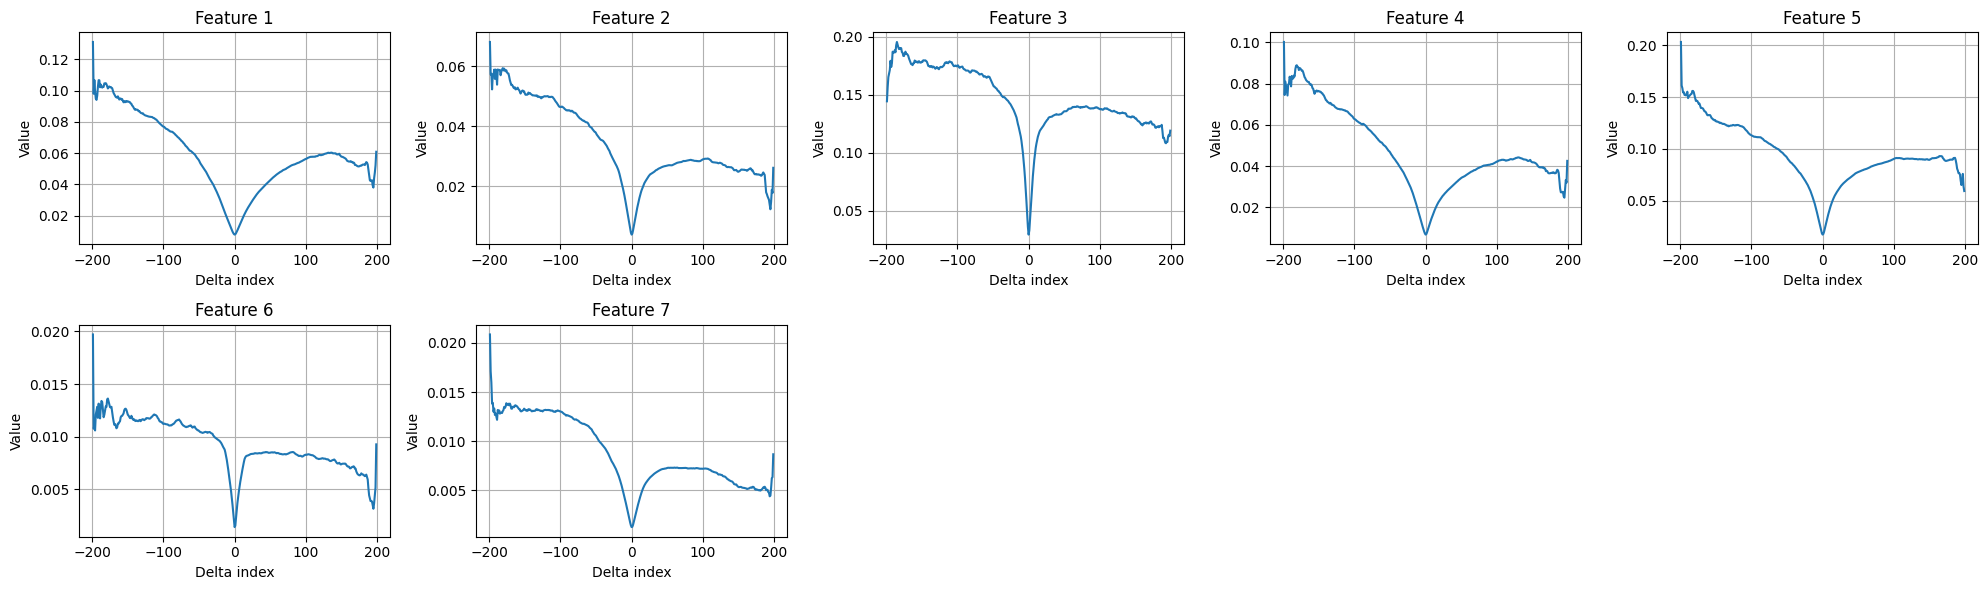

In [9]:
plot_delta_features(mean_feature_errors)

In [10]:
import numpy as np

import numpy as np

def weighted_mean_from_array(arr, baseline=None):
    """
    Compute weighted mean across features and normalize to [0,1].
    
    arr: np.ndarray of shape (F, x)
    baseline: optional array of shape (F,), baseline value of each feature. 
              If None, minimum across x is used.
    
    Returns:
        x_mean: np.ndarray of shape (x,), weighted mean normalized to [0,1]
        weights: np.ndarray of shape (F,), the calculated feature weights
    """
    F, x = arr.shape

    # Compute baseline if not provided
    if baseline is None:
        baseline = np.nanmin(arr, axis=1)  # (F,)
    
    # Compute dynamic range of each feature
    feature_range = np.nanmax(arr, axis=1) - baseline  # (F,)

    # Weight: higher range → higher weight, smaller baseline → higher weight
    weights = feature_range / (feature_range.sum() + 1e-8)
    
    # Weighted mean across features
    x_mean = np.nansum(arr * weights[:, None], axis=0)
    
    # Normalize to [0,1]
    min_val = np.nanmin(x_mean)
    max_val = np.nanmax(x_mean)
    if max_val - min_val > 0:
        x_mean = (x_mean - min_val) / (max_val - min_val)
    else:
        x_mean = np.zeros_like(x_mean)

    return x_mean, weights

valid_combined_error,weights = weighted_mean_from_array(mean_feature_errors)

print(weights)

[0.18355992 0.09568655 0.24743241 0.13924494 0.2776137  0.02726911
 0.02919334]


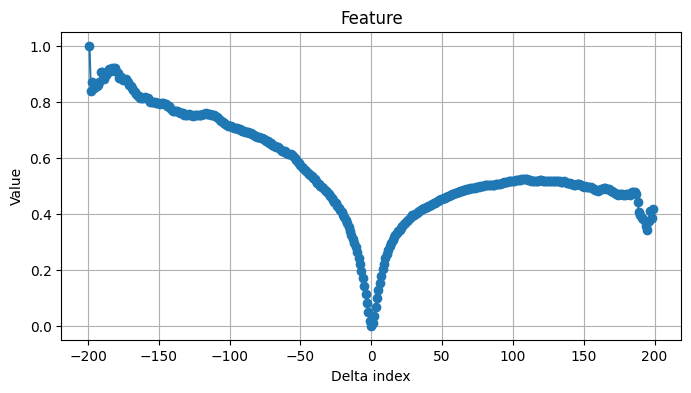



1.0
0.009006525


0.9006525


In [11]:



plot_single_feature(valid_combined_error)

valid_maxima = np.nanmax(valid_combined_error)
valid_base = valid_combined_error[eff_Dmax]

print("\n")
print(valid_maxima)
print(valid_base)
print("\n")
print((valid_base/valid_maxima)*100)